# 🦠 Analisi del Dataset COVID-19

Utilizzando il **file CSV fornito**, convertire i dati in **DataFrame** ed eseguire le seguenti operazioni:

## 7️⃣ Evoluzione dei casi confermati e recuperati in Spagna

**📂 File da utilizzare:** COVID_01-01-2021.csv e i file dei mesi successivi

**Obiettivo:**
- Visualizzare l'evoluzione dei **casi confermati** e dei **pazienti recuperati** di coronavirus.
- Confrontare le diverse **province della Spagna** durante il **primo trimestre del 2021**.
- 📈 Creare grafici chiari che mostrino le tendenze nel tempo per ciascuna provincia.

Caricato: COVID_01-01-2021.csv
Caricato: COVID_01-02-2021.csv
Caricato: COVID_01-03-2021.csv


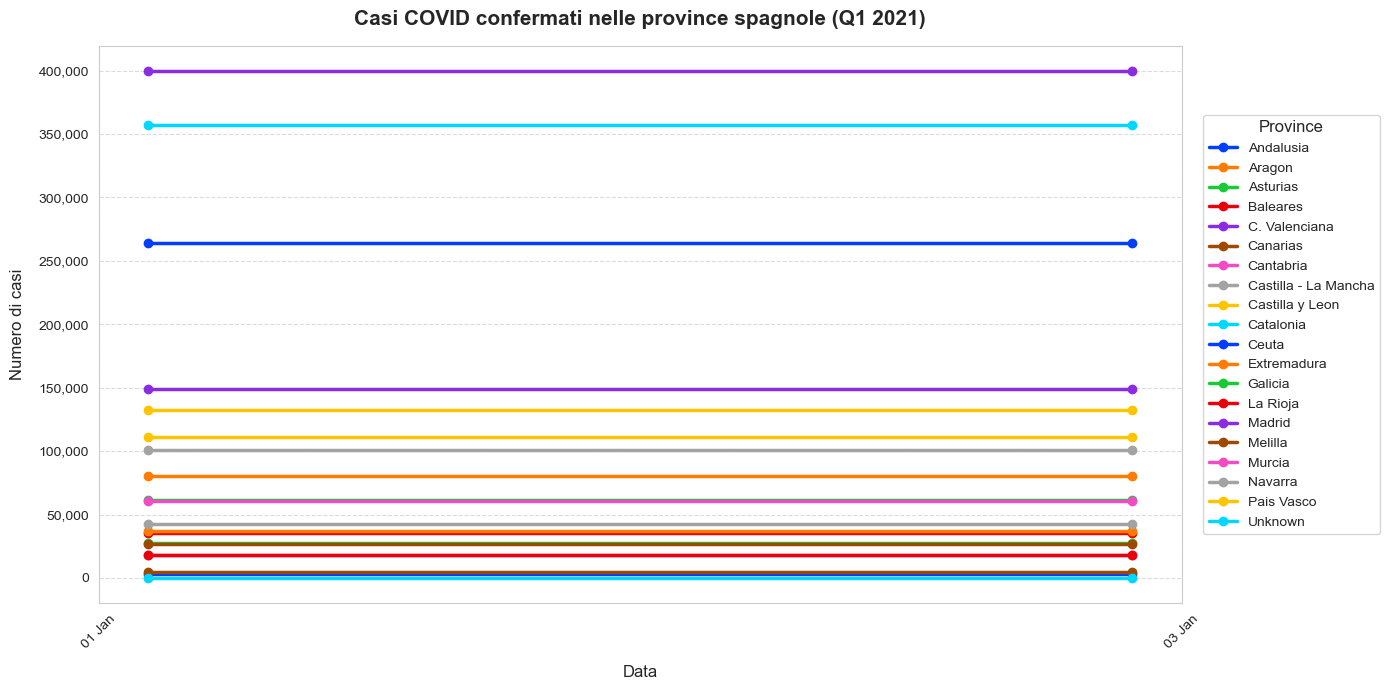

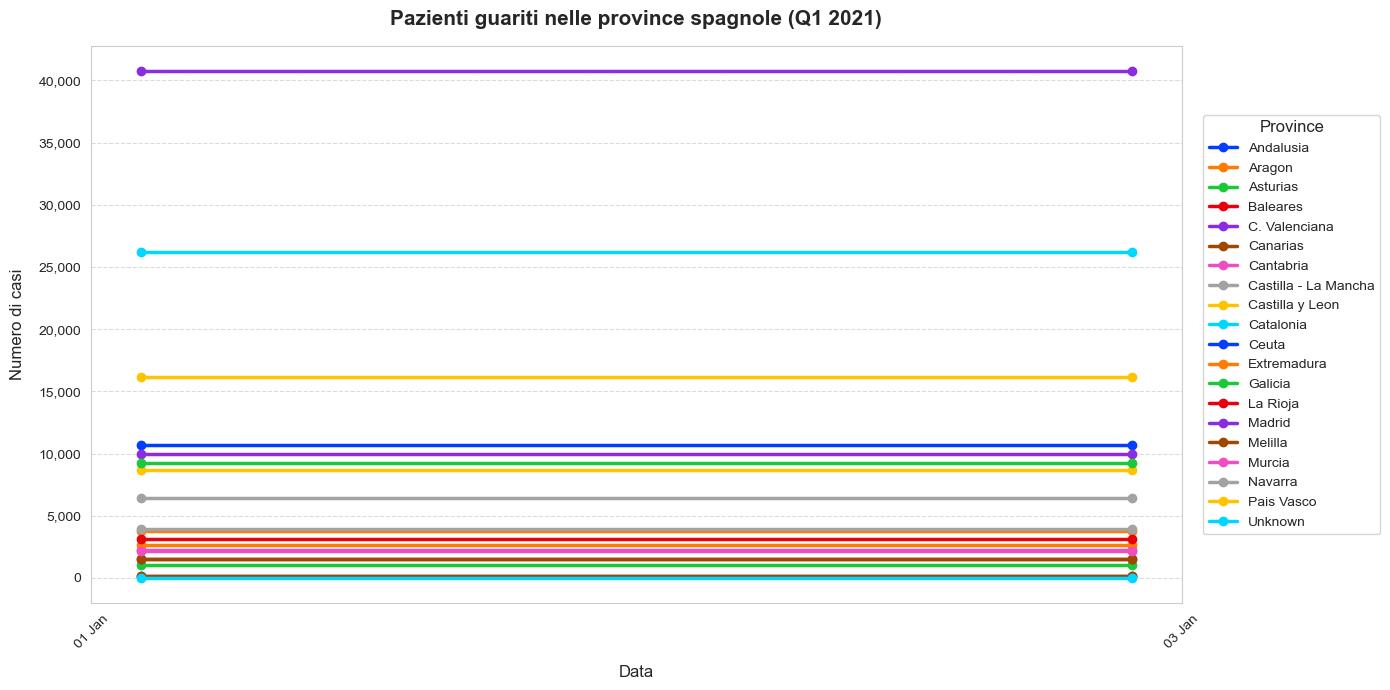

Analisi completata: 20 province analizzate


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from datetime import datetime

# Impostazione di uno stile grafico esteticamente migliorato
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# Percorsi dei file (primo trimestre 2021)
file_dati = [
    "COVID_01-01-2021.csv",
    "COVID_01-02-2021.csv",
    "COVID_01-03-2021.csv"
]

# Caricamento dei dati
tutti_dati = []

for file in file_dati:
    try:
        # Leggiamo solo le colonne necessarie
        dati = pd.read_csv(file, usecols=["Province_State", "Country_Region", "Confirmed", "Recovered"])
        
        # Estraiamo la data dal nome del file
        stringa_data = os.path.basename(file).split("COVID_")[1].split(".csv")[0]
        dati["Data"] = pd.to_datetime(stringa_data, format="%m-%d-%Y")

        # Aggiungiamo il dataframe alla lista
        tutti_dati.append(dati)
        print(f"Caricato: {os.path.basename(file)}")
        
    except Exception as errore:
        # Gestione degli errori in caso di problemi nel caricamento
        print(f"Errore: {errore}")

# Preparazione dei dati
if tutti_dati:
    
    # Uniamo tutti i dataframe e filtriamo per la Spagna
    dati_uniti = pd.concat(tutti_dati, ignore_index=True)
    dati_spagna = dati_uniti[dati_uniti["Country_Region"] == "Spain"].copy()
    
    # Aggregazione per data e provincia
    dati_aggregati = (dati_spagna.groupby(["Data", "Province_State"]).sum().reset_index())
    province = sorted(dati_aggregati["Province_State"].unique())
    
    # Palette di colori più vivaci per i grafici
    colori = sns.color_palette("bright", len(province))
    
    # Funzione per creare grafici con linee più evidenti e legenda a destra
    def crea_grafico(tipo_dato, titolo, nome_file):
        
        # Creiamo una figura più ampia per ospitare la legenda a destra
        plt.figure(figsize=(14, 7))
        
        for i, provincia in enumerate(province):
            dati_provincia = dati_aggregati[dati_aggregati["Province_State"] == provincia]
            
            plt.plot(
                dati_provincia["Data"],
                dati_provincia[tipo_dato],
                label=provincia,
                linewidth=2.5,
                marker='o',
                markersize=6,
                color=colori[i])
        
        # Formattazione asse X
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        
        plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
        
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # Formattazione numeri asse Y
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
        
        # Titoli e stile
        plt.title(titolo, fontsize=15, fontweight='bold', pad=15)
        plt.xlabel("Data", fontsize=12, labelpad=10)
        plt.ylabel("Numero di casi", fontsize=12, labelpad=10)
        
        # Legenda a destra del grafico
        plt.legend(
            title="Province",
            title_fontsize=12,
            fontsize=10,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0)
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(nome_file, dpi=300, bbox_inches='tight')
        plt.show()
    
    # Grafico casi confermati
    crea_grafico(
        "Confirmed",
        "Casi COVID confermati nelle province spagnole (Q1 2021)",
        "casi_confermati.png")
    
    # Grafico pazienti guariti
    crea_grafico(
        "Recovered",
        "Pazienti guariti nelle province spagnole (Q1 2021)",
        "pazienti_guariti.png")
    
    # Riepilogo finale
    print(f"Analisi completata: {len(province)} province analizzate")

else:
    print("Nessun dato caricato. Verifica i percorsi dei file.")